**Instituto Tecnológico de Aeronáutica – ITA**

**Aprendizado Profundo – CM-204**

**Professor:**

Marcos Ricardo Omena de Albuquerque Maximo

# Laboratório 2 – Aprendizado Profundo

# 1.	Introdução

Nesse laboratório, seu objetivo é copiar um movimento de caminhar de um robô humanoide usando uma técnica chamada *imitation learning* (aprendizado por imitação). Para isso, você usará o *framework* de Aprendizado Profundo PyTorch. A Figura 1 mostra uma comparação entre o movimento da junta do quadril de arfagem obtida através de “observação” da caminhada de um robô humanoide e o mesmo movimento conforme “copiado” por uma rede neural.


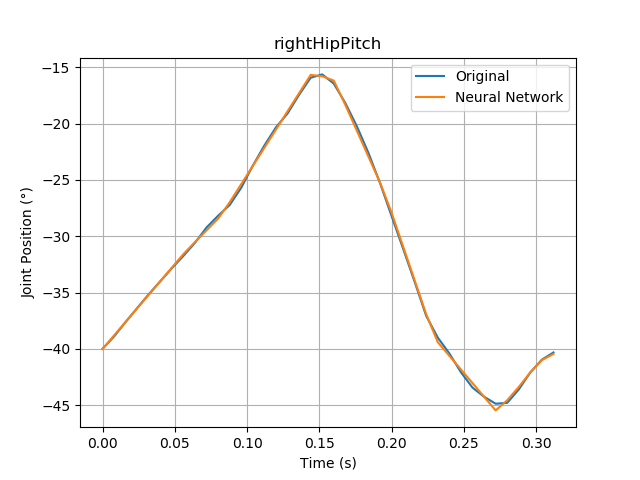

**Figura 1**: imitação do movimento da junta do quadril de arfagem através de uma rede neural.


# 2. Descrição do Problema

O problema a ser resolvido nesse laboratório é copiar o movimento de caminhar de um robô humanoide usando uma técnica chamada *imitation learning*. Nessa técnica, copia-se uma política de controle usando aprendizado supervisionado. Para a implementação da rede neural, você utilizará o *framework* PyTorch.

O exemplo de treinamento consiste nas posições angulares das 20 juntas do robô durante um ciclo de caminhada, que foram obtidas através da “observação” das juntas do robô enquanto ele caminhava. O algoritmo de caminhada original é baseado em teoria de Controle. A entrada da rede é o tempo dentro do ciclo de caminhada (apenas 1 entrada), enquanto a saída consiste nas posições das 20 juntas. Sugere-se que a rede a ser implementada deve seguir a arquitetura apresentada na Tabela 1.


| **Layer** | **Neurons** | **Activation Function** |
|--------------|------------------|------------------------------|
| *Dense*        | 75               | *Leaky* ReLU ($\alpha=0.01$)   |
| *Dense*        | 50               | *Leaky* ReLU ($\alpha=0.01$)   |
| *Dense*        | 20               | *Linear*                       |

<p align="center">
<b>Tabela 1</b>: arquitetura da rede neural usada para o <i>imitation learning</i>. </p>


# 3.	Código Base

O código base já implementa um exemplo para familiarização com como implementar uma rede neural em PyTorch. Então, você deve implementar a rede neural usada para o *imitation learning* seguindo mais ou menos as mesmas ideias (há dicas no final do roteiro para te ajudar caso ainda tenha dificuldades).

# 4. Tarefas

Comece rodando a célula abaixo para fazer o *download* da base de dados e do arquivo utils.py com funções utilitárias.

In [24]:
import zipfile
import os

# download data (MUST RUN)
!gdown --id 1EvoMgCiS-1kXZYzOU5_ODF-qQK2FnqOq

with zipfile.ZipFile("cm204_lab2_data.zip","r") as zip_ref:
  zip_ref.extractall() # extracts in current directory

# make results folder to save images
if not os.path.exists('results'):
  os.makedirs('results')

os.remove("cm204_lab2_data.zip")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1EvoMgCiS-1kXZYzOU5_ODF-qQK2FnqOq
To: /content/cm204_lab2_data.zip
100% 12.7k/12.7k [00:00<00:00, 36.7MB/s]


## 4.1. Estudo de Implementação de Rede Neural com PyTorch

Primeiramente, estude a implementação nas células abaixo para aprender como implementar uma rede neural com PyTorch.

## 4.2. Análise do Efeito de Regularização

A célula a seguir define um laço (*loop*) de treinamento para uma rede neural. Recomenda-se que você tente entendê-la linha a linha. Veja que o procedimento é semelhante ao adotado para realizar a otimização por Descida do Gradiente.

In [25]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

def train(model : nn.Module, dataloader : DataLoader, loss_fn : nn.Module, optimizer : torch.optim.Optimizer, num_epochs : int = 50) -> list:
    """
    Trains the given model using the provided dataloader, loss function, and optimizer for a specified number of epochs.
    Args:
        model: The neural network model to be trained.
        dataloader: The DataLoader providing the training data.
        loss_fn: The loss function to be used for training.
        optimizer: The optimizer to be used for updating the model parameters.
        num_epochs (int): The number of epochs to train the model.
    """
    # This list is used to store the loss value at each epoch for plotting the cost function convergence
    loss_history = []

    model.train() # Sets the model to training mode
    for epoch in range(num_epochs):
        epoch_loss = 0.0 # To store the loss for the current epoch
        for batch, (X, y) in enumerate(dataloader):
            pred = model(X) # Forward pass to compute the predicted output
            loss = loss_fn(pred, y) # Computes the loss between the predicted output and the expected output
            optimizer.zero_grad() # Clears the gradients of all optimized tensors
            loss.backward() # Backpropagation to compute gradients
            optimizer.step() # Update model parameters using the optimizer
            epoch_loss += loss.item() # Accumulate the loss for the current epoch
        loss_history.append(epoch_loss / len(dataloader)) # Store the average loss for the current epoch
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss_history[-1]:.6f}")

    return loss_history

A célula a seguir cria e treina uma rede neural *feedforward* que recebe duas entradas $x_1$ e $x_2$ e então aprende a realizar uma das detecções a seguir (selecionável através do parâmetro `classification_function`):

1. `sum_gt_zero`: $x_1 + x_2 \geq 0$.
2. `xor`: $x_1 \oplus x_2$ (ou exclusivo).

Caso queira verificar, as funções `sum_gt_zero` e `xor` estão implementadas no arquivo `utils.py`. Recomenda-se verificar a função linha a linha.

Execute seu código com as quatro combinações possíveis de `lambda_l2` e `classification_function`. Coloque os gráficos com limite de decisão de cada rede neural (último gráfico gerado pela célula) no seu relatório e discuta os resultados obtidos.

Epoch 1/5000, Loss: 0.649462
Epoch 2/5000, Loss: 0.629410
Epoch 3/5000, Loss: 0.610727
Epoch 4/5000, Loss: 0.592909
Epoch 5/5000, Loss: 0.574583
Epoch 6/5000, Loss: 0.557962
Epoch 7/5000, Loss: 0.541504
Epoch 8/5000, Loss: 0.525451
Epoch 9/5000, Loss: 0.510317
Epoch 10/5000, Loss: 0.495917
Epoch 11/5000, Loss: 0.481550
Epoch 12/5000, Loss: 0.467999
Epoch 13/5000, Loss: 0.455072
Epoch 14/5000, Loss: 0.442644
Epoch 15/5000, Loss: 0.430536
Epoch 16/5000, Loss: 0.419109
Epoch 17/5000, Loss: 0.407895
Epoch 18/5000, Loss: 0.397602
Epoch 19/5000, Loss: 0.387361
Epoch 20/5000, Loss: 0.377575
Epoch 21/5000, Loss: 0.368092
Epoch 22/5000, Loss: 0.359257
Epoch 23/5000, Loss: 0.350542
Epoch 24/5000, Loss: 0.342379
Epoch 25/5000, Loss: 0.334383
Epoch 26/5000, Loss: 0.326858
Epoch 27/5000, Loss: 0.319578
Epoch 28/5000, Loss: 0.312758
Epoch 29/5000, Loss: 0.305985
Epoch 30/5000, Loss: 0.299461
Epoch 31/5000, Loss: 0.293378
Epoch 32/5000, Loss: 0.287450
Epoch 33/5000, Loss: 0.281858
Epoch 34/5000, Loss

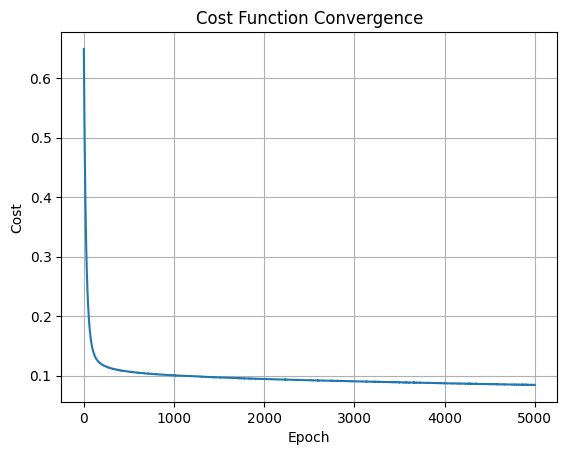

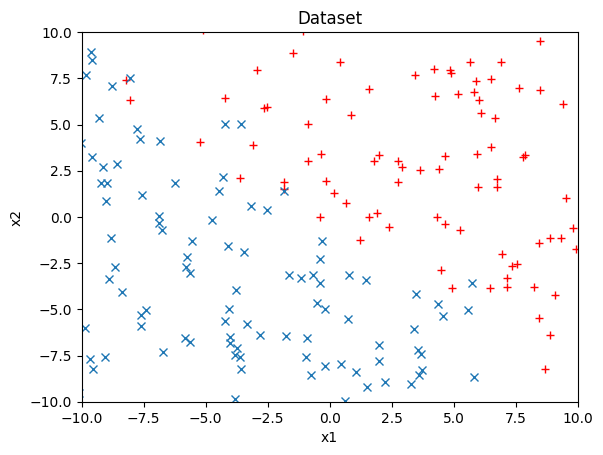

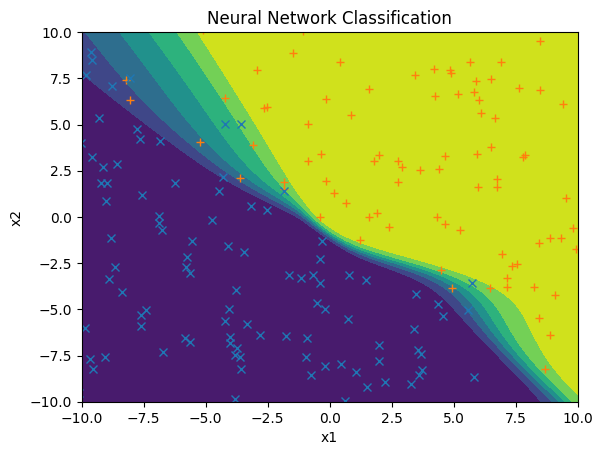

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from utils import sum_gt_zero, xor

# Play with the following parameters to see their effect on the training of the neural network and the resulting decision regions
lambda_l2 = 0.000  # lambda parameter of the L2 regularization
#lambda_l2 = 0.002  # lambda parameter of the L2 regularization
classification_function = sum_gt_zero  # selects sum_gt_zero as the classification function
#classification_function = xor  # selects xor as the classification function

num_cases = 200  # number of auto-generated cases
num_epochs = 5000  # number of epochs for training
# Figure format used for saving figures
fig_format = 'png'
# fig_format = 'svg'
# fig_format = 'eps'

if classification_function == sum_gt_zero:
    function_name = 'sgz'
else:
    function_name = 'xor'

# Setting the random seeds for reproducibility reasons
np.random.seed(42)
torch.manual_seed(42)

# Creating the dataset
inputs = 10.0 * (-1.0 + 2.0 * np.random.rand(num_cases, 2))
expected_outputs = np.array([classification_function(x) for x in inputs])
inputs += 2.0 * (-1.0 + 2.0 * np.random.rand(num_cases, 2))  # adding noise to corrupt the dataset

# Separating the dataset into positive and negative samples
positives_array = inputs[expected_outputs >= 0.5, :]
negatives_array = inputs[expected_outputs < 0.5, :]

# Defines a feedforward neural network with one input layer with two neurons,
# one hidden layer with 50 neurons and sigmoid activation function,
# and one output layer with one neuron and sigmoid activation function
model = nn.Sequential(
    nn.Linear(2, 50),
    nn.Sigmoid(),
    nn.Linear(50, 1),
    nn.Sigmoid()
)

# Defines the optimizer and the loss function for training the model
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=lambda_l2)
loss_fn = nn.BCELoss() # BCELoss is the binary cross-entropy loss function

# Converts the inputs and expected outputs to PyTorch tensors
inputs_torch = torch.tensor(inputs, dtype=torch.float32)
expected_outputs_torch = torch.tensor(expected_outputs, dtype=torch.float32).unsqueeze(1)

# Creating the dataset and dataloader for training the model
dataset = TensorDataset(inputs_torch, expected_outputs_torch)
dataloader = DataLoader(dataset, batch_size=num_cases // 4, shuffle=True)
# The dataloader is a PyTorch utility that provides an iterable over the given dataset, with support for automatic batching, shuffling, and parallel data loading.

loss_history = train(model, dataloader, loss_fn, optimizer, num_epochs=num_epochs)

# Plotting cost function convergence
plt.plot(np.array(loss_history))
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Cost Function Convergence')
plt.grid()
plt.savefig('results/convergence_' + function_name + '_l' + str(lambda_l2) + '.' + fig_format, format=fig_format)

# Plotting positive and negative samples
plt.figure()
plt.plot(positives_array[:, 0], positives_array[:, 1], '+r')
plt.plot(negatives_array[:, 0], negatives_array[:, 1], 'x')
plt.xlim([-10.0, 10.0])
plt.ylim([-10.0, 10.0])
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Dataset')
plt.savefig('results/dataset_' + function_name + '_l' + str(lambda_l2) + '.' + fig_format, format=fig_format)

# Plotting the decision regions of the neural network
plt.figure()
x = np.arange(-10.0, 10.05, 0.05)
y = np.arange(-10.0, 10.05, 0.05)
X, Y = np.meshgrid(x, y)
x = np.reshape(X, (np.size(X, 0) * np.size(X, 1), 1))
y = np.reshape(Y, (np.size(Y, 0) * np.size(Y, 1), 1))
input = np.concatenate((x, y), axis=1)
z = model.forward(torch.tensor(input, dtype=torch.float32)).detach().numpy()
Z = z.reshape((np.size(X, 0), np.size(Y, 0)))
plt.contourf(X, Y, Z)
plt.xlim([-10.0, 10.0])
plt.ylim([-10.0, 10.0])
plt.plot(positives_array[:, 0], positives_array[:, 1], '+', color='tab:orange')
plt.plot(negatives_array[:, 0], negatives_array[:, 1], 'x')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Neural Network Classification')
plt.savefig('results/nn_classification_' + function_name + '_l' + str(lambda_l2) + '.' + fig_format, format=fig_format)

## 4.3. *Imitation Learning*

Usando PyTorch, implemente uma rede neural de acordo com a arquitetura apresentada na Tabela 1. Leve em consideração o seguinte para o treinamento:

- Não use regularização.
- Use todo o *dataset* em cada iteração do treinamento.
- Use erro quadrático como *loss* (`MSELoss`).
- Coloque os gráficos gerados no seu relatório e discuta os resultados.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# Joints' order in the dataset
joints_dict = dict()
joints_dict['leftAnklePitch'] = 0
joints_dict['leftAnkleRoll'] = 1
joints_dict['leftElbowYaw'] = 2
joints_dict['leftHipPitch'] = 3
joints_dict['leftHipRoll'] = 4
joints_dict['leftHipYaw'] = 5
joints_dict['leftKneePitch'] = 6
joints_dict['leftShoulderPitch'] = 7
joints_dict['leftShoulderRoll'] = 8
joints_dict['neckPitch'] = 9
joints_dict['neckYaw'] = 10
joints_dict['rightAnklePitch'] = 11
joints_dict['rightAnkleRoll'] = 12
joints_dict['rightElbowYaw'] = 13
joints_dict['rightHipPitch'] = 14
joints_dict['rightHipRoll'] = 15
joints_dict['rightHipYaw'] = 16
joints_dict['rightKneePitch'] = 17
joints_dict['rightShoulderPitch'] = 18
joints_dict['rightShoulderRoll'] = 19

right_leg_joints = ['rightHipRoll', 'rightHipPitch', 'rightKneePitch', 'rightAnklePitch', 'rightAnkleRoll']

num_epochs = 30000  # number of epochs for training
# Figure format used for saving figures
fig_format = 'png'
# fig_format = 'svg'
# fig_format = 'eps'

# Loading the dataset
positions = np.loadtxt('positions.txt')
# The dataset contains the walking cycles, but we will use only the first one for training
expected_output = positions[0:40, :]
# Creating a input vector (0.008 ms is the sample time of the walking algorithm)
input = 0.008 * np.arange(0, expected_output.shape[0])

# Setting the random seed of numpy's random library for reproducibility reasons
np.random.seed(42)
torch.manual_seed(42)

$\color{red}{\textbf{Implemente aqui a rede neural usando PyTorch}}$

❗ ❗ Descomente a penúltima linha e remova a última, conforme os comentários.

In [28]:
inputs_torch = torch.tensor(input, dtype=torch.float32).unsqueeze(1)
expected_outputs_torch = torch.tensor(expected_output, dtype=torch.float32)

# Todo: Implement and train the neural network using PyTorch
# neural network implementation
model = nn.Sequential(
    nn.Linear(1,75),
    nn.LeakyReLU(0.01),

    nn.Linear(75,50),
    nn.LeakyReLU(0.01),

    nn.Linear(50,20)
)

# neural network training
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# Creating the dataset and dataloader for training the model
dataset = TensorDataset(inputs_torch, expected_outputs_torch)
dataloader = DataLoader(dataset, batch_size = len(dataset), shuffle=True)

# Training history
loss_history = train(model, dataloader, loss_fn, optimizer, num_epochs = num_epochs)

# Predict the output from the Neural Network
input_predict = np.arange(0, input[-1] + 0.001, 0.001)
output = model.forward(torch.tensor(input_predict, dtype=torch.float32).unsqueeze(1)).detach().numpy()  # add this line to predict the output from the Neural Network


A saída de streaming foi truncada nas últimas 5000 linhas.
Epoch 25001/30000, Loss: 0.000040
Epoch 25002/30000, Loss: 0.000040
Epoch 25003/30000, Loss: 0.000040
Epoch 25004/30000, Loss: 0.000040
Epoch 25005/30000, Loss: 0.000040
Epoch 25006/30000, Loss: 0.000040
Epoch 25007/30000, Loss: 0.000040
Epoch 25008/30000, Loss: 0.000040
Epoch 25009/30000, Loss: 0.000040
Epoch 25010/30000, Loss: 0.000040
Epoch 25011/30000, Loss: 0.000040
Epoch 25012/30000, Loss: 0.000040
Epoch 25013/30000, Loss: 0.000040
Epoch 25014/30000, Loss: 0.000040
Epoch 25015/30000, Loss: 0.000040
Epoch 25016/30000, Loss: 0.000040
Epoch 25017/30000, Loss: 0.000040
Epoch 25018/30000, Loss: 0.000040
Epoch 25019/30000, Loss: 0.000040
Epoch 25020/30000, Loss: 0.000040
Epoch 25021/30000, Loss: 0.000041
Epoch 25022/30000, Loss: 0.000041
Epoch 25023/30000, Loss: 0.000042
Epoch 25024/30000, Loss: 0.000043
Epoch 25025/30000, Loss: 0.000044
Epoch 25026/30000, Loss: 0.000046
Epoch 25027/30000, Loss: 0.000048
Epoch 25028/30000, Loss

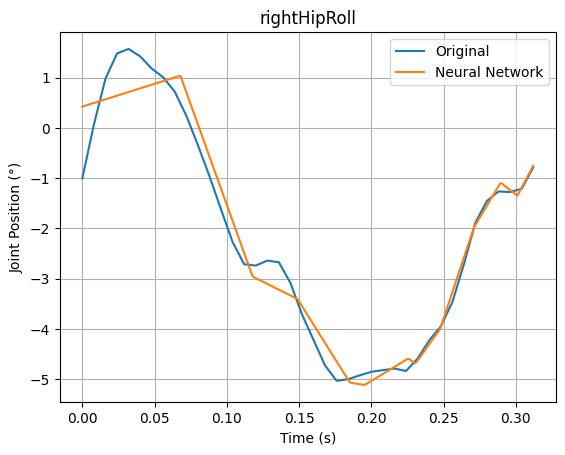

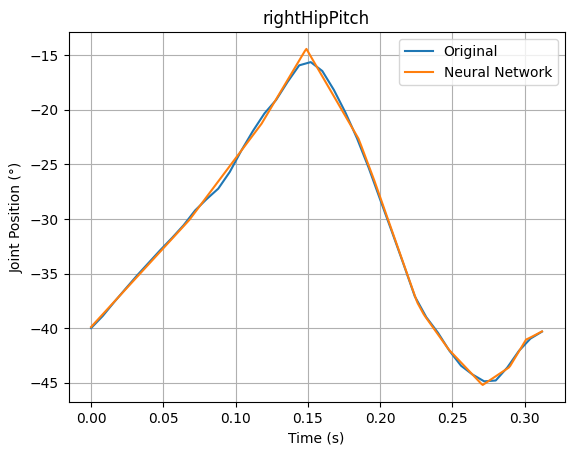

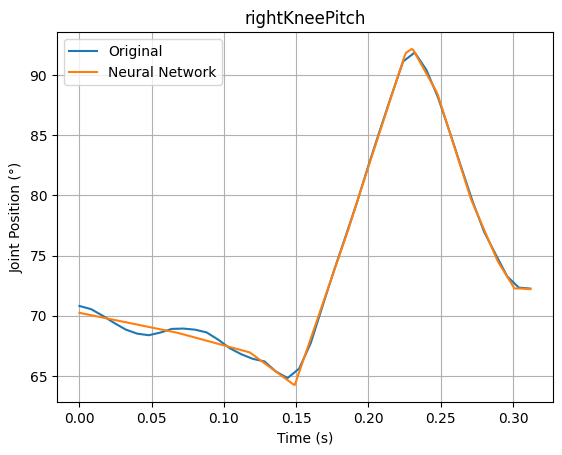

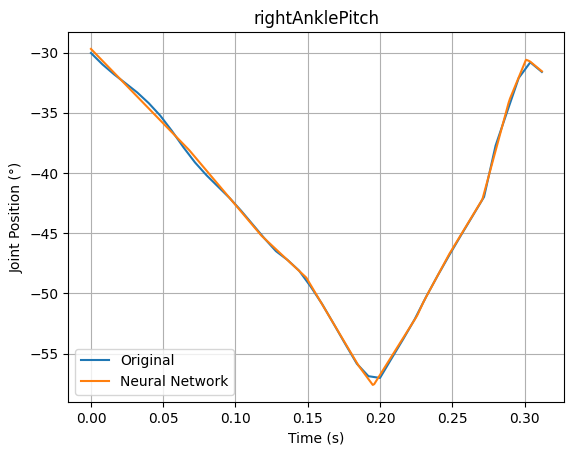

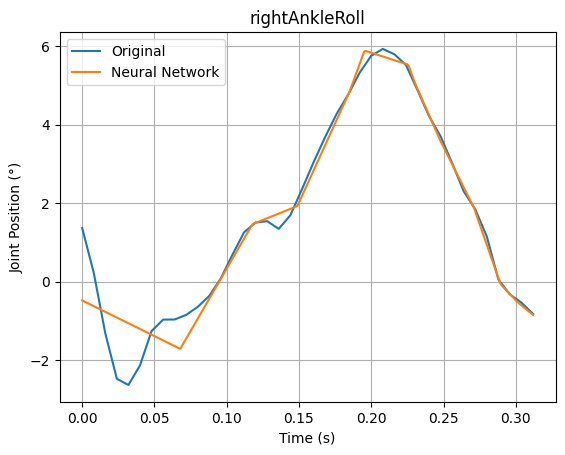

In [29]:
# Comparing original and copied joint trajectories to evaluate the imitation learning
for joint in right_leg_joints:
    plt.figure()
    plt.plot(input, expected_output[:, joints_dict[joint]] * 180.0 / pi)
    plt.plot(input_predict, output[:, joints_dict[joint]] * 180.0 / pi)
    plt.grid()
    plt.title(joint)
    plt.xlabel('Time (s)')
    plt.ylabel('Joint Position (°)')
    plt.legend(['Original', 'Neural Network'])
    plt.savefig('results/' + joint + '.' + fig_format, format=fig_format)
plt.show()

# 5. Entrega

A entrega consiste do notebook no formato **.ipynb** e de um relatório, submetida através do Google Classroom. Modificações nos arquivos do código base são permitidas, desde que o nome e a interface dos scripts “main” não sejam alterados. A princípio, não há limitação de número de páginas para o relatório, mas pede-se que seja sucinto. O relatório deve conter:

- Breve descrição em alto nível da sua implementação.
- Figuras que comprovem o funcionamento do seu código.

Por limitações do Google Classroom (e por motivo de facilitar a automatização da correção), entregue seu laboratório com todos os arquivos num único arquivo **.zip** (**não** utilize outras tecnologias de compactação de arquivos) com o seguinte padrão de nome: **“<login_email_google_education>_labX.zip”**. Por exemplo, no meu caso, meu login Google Education é **marcos.maximo**, logo eu entregaria o lab 1 como **“marcos.maximo_lab1.zip”**. **Não** crie subpastas para os arquivos da sua entrega, **deixe todos os arquivos na “raiz” do .zip**. Os relatórios devem ser entregues em formato **.pdf**.

# 6. Dicas

- Para adicionar função de ativação LeakyRelu, use `nn.LeakyRelu`.

- Conforme está mostrado no exemplo, na primeira camada da rede, é importante definir qual é a dimensão da entrada.

- Para usar todos os dados de treinamento durante o treinamento da rede, coloque o tamanho do *batch* igual ao tamanho do *dataset*.

- Para fazer o download das figuras e usá-las no relatório, use os seguintes comandos:
```python
from google.colab import files
import os
os.system('zip -r lab2_results.zip results')
files.download("lab2_results.zip")
```